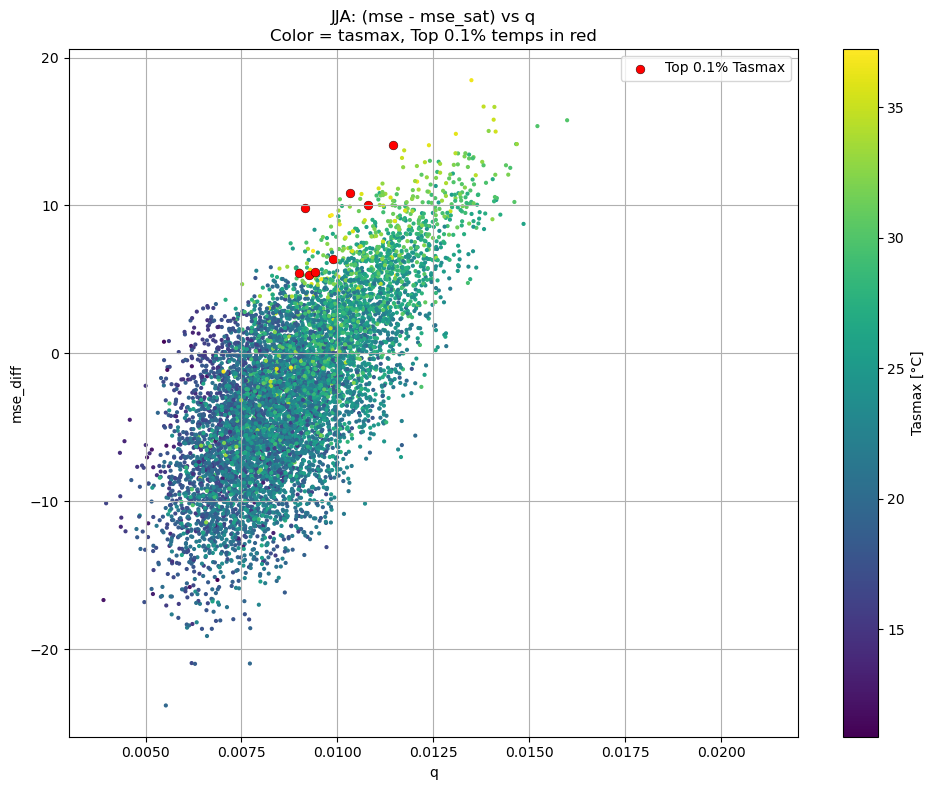

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Load dataset
# -------------------------------------------------------------
ds = xr.open_dataset("/work/uc1275/u301827/02_MSE/paris/era5_mse_full_1940_2024_new.nc")

# -------------------------------------------------------------
# 2. Select JJA days
# -------------------------------------------------------------
jja = ds.sel(time=ds.time.dt.month.isin([6, 7, 8]))

# -------------------------------------------------------------
# 3. Extract variables
# -------------------------------------------------------------
# mse: (time, lat, lon, lev)
# mse_sat: (time, lat, lon)
# q: (time, lev, lat, lon)

mse = jja["mse"]
mse_sat = jja["mse_sat"]
q = jja["q"]
tasmax = jja["tasmax"]-273.15

# Compute mse - mse_sat (broadcast automatically)
mse_diff = mse - mse_sat

# -------------------------------------------------------------
# 4. Flatten all arrays for scatter plotting
# -------------------------------------------------------------
# Collapse all spatial dims → 1D arrays
x = mse_diff.values.ravel()  # mse - mse_sat
y = q.values.ravel()         # specific humidity
c = tasmax.values.ravel()    # tasmax color gradient

# Remove NaNs
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(c)
x = x[mask]
y = y[mask]
c = c[mask]

# -------------------------------------------------------------
# 5. Identify top 0.1% Tasmax events
# -------------------------------------------------------------
thr = np.percentile(c, 99.9)
hot = c >= thr

# -------------------------------------------------------------
# 6. Plot
# -------------------------------------------------------------
plt.figure(figsize=(10, 8))

# Main scatter: tasmax as colormap
sc = plt.scatter(
    y[~hot], x[~hot],
    c=c[~hot],
    s=4,
    alpha=1.
)

# Highlight hottest 0.1%
plt.scatter(
    y[hot], x[hot],
    color='red',
    s=40,
    edgecolor='black',
    linewidth=0.3,
    label='Top 0.1% Tasmax'
)

# Colorbar
cb = plt.colorbar(sc)
cb.set_label("Tasmax [°C]")

plt.ylabel("mse_diff")
plt.xlabel("q")
plt.title("JJA: (mse - mse_sat) vs q\nColor = tasmax, Top 0.1% temps in red")
plt.grid()
plt.xlim(0.003,0.022)
#plt.ylim(-30,30)
plt.legend()
plt.tight_layout()
plt.savefig('JJA_msesurf_era5.pdf')
plt.show()


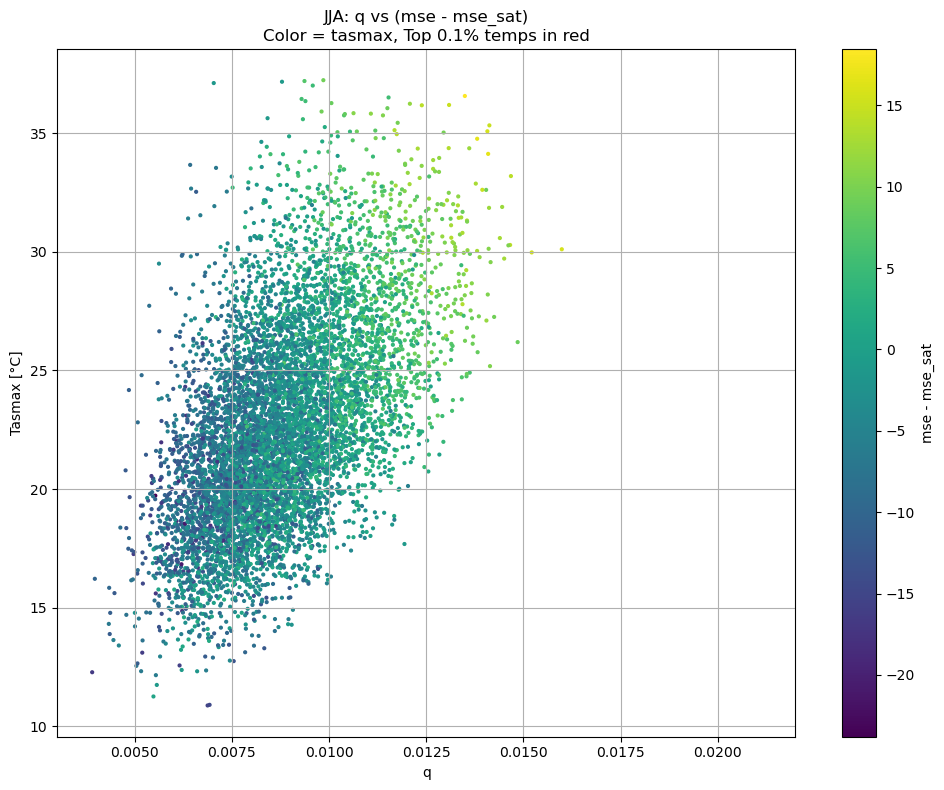

In [2]:
# -------------------------------------------------------------
# 1. Load dataset
# -------------------------------------------------------------
ds = xr.open_dataset("/work/uc1275/u301827/02_MSE/paris/era5_mse_full_1940_2024_new.nc")

# -------------------------------------------------------------
# 2. Select JJA days
# -------------------------------------------------------------
jja = ds.sel(time=ds.time.dt.month.isin([6, 7, 8]))

# -------------------------------------------------------------
# 3. Extract variables
# -------------------------------------------------------------
# mse: (time, lat, lon, lev)
# mse_sat: (time, lat, lon)
# q: (time, lev, lat, lon)

mse = jja["mse"]
mse_sat = jja["mse_sat"]
q = jja["q"]
tasmax = jja["tasmax"]-273.15

# Compute mse - mse_sat (broadcast automatically)
mse_diff = mse - mse_sat

# -------------------------------------------------------------
# 4. Flatten all arrays for scatter plotting
# -------------------------------------------------------------
# Collapse all spatial dims → 1D arrays
x = mse_diff.values.ravel()  # mse - mse_sat
y = q.values.ravel()         # specific humidity
c = tasmax.values.ravel()    # tasmax color gradient

# Remove NaNs
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(c)
x = x[mask]
y = y[mask]
c = c[mask]

# -------------------------------------------------------------
# 5. Identify top 0.1% Tasmax events
# -------------------------------------------------------------
thr = np.percentile(c, 99.9)
hot = c >= thr

plt.figure(figsize=(10, 8))

# Main scatter: tasmax as colormap
# --> x and y swapped here
sc = plt.scatter(
    y[~hot], c[~hot],
    c=x[~hot],
    s=4,
    alpha=1.
)

# Colorbar (still mapped to tasmax)
cb = plt.colorbar(sc)
cb.set_label("mse - mse_sat")

plt.ylabel("Tasmax [°C]")
plt.xlabel("q")
plt.title("JJA: q vs (mse - mse_sat)\nColor = tasmax, Top 0.1% temps in red")
plt.grid()
plt.xlim(0.003, 0.022)
plt.tight_layout()
plt.savefig("JJA_msesurf_era5_swapped.pdf")
plt.show()


In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import metpy.calc as mpcalc
from metpy.units import units

# Load and spatially average
ds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/paris/era5_mse_full_1940_2024_new.nc"
).mean(['lat', 'lon'])

# --- Relative humidity (unchanged) ---
t2m_units = ds.t2m * units.kelvin
td2m_units = ds.td2m * units.kelvin

ds["rh"] = mpcalc.relative_humidity_from_dewpoint(t2m_units, td2m_units)

# --- ERA5 flux handling (IMPORTANT) ---
# ERA5 convention: positive downward, negative upward
H  = -ds.sshf   # upward sensible heat flux
LE = -ds.slhf   # upward latent heat flux

# --- Mask non-physical EF times ---
# EF is only defined when both fluxes are upward
valid = (H > 0) & (LE > 0)

ds["EF"] = (LE / (LE + H)).where(valid)

ds["evf"] = ds.e/ds.pev
# Final dataset
ds_era = ds


In [11]:
tasmax = ds["tasmax"]

# -----------------------------------------------------------
# 1. Find TXx date per year
# -----------------------------------------------------------
def get_txx_date(da):
    idx = da.argmax(dim="time")
    return da.time.isel(time=idx)

txx_dates = tasmax.groupby("time.year").apply(get_txx_date)

# Synthetic composite time axis: -3 ... +3
composite_time = xr.DataArray(np.arange(-3, 4), dims="time", name="time")

# -----------------------------------------------------------
# 2. Extract ±3-day windows and align to synthetic time axis
# -----------------------------------------------------------
composite_list = []

for year in txx_dates.year.values:
    txx_day = pd.to_datetime(str(txx_dates.sel(year=year).values))
    
    # Get 7 exact timestamps
    window_times = [txx_day + pd.Timedelta(days=i) for i in range(-3, 4)]
    
    # Select these exact times
    comp = ds.sel(time=window_times)
    
    # Replace actual timestamps by synthetic [-3..3]
    comp = comp.assign_coords(time=composite_time)
    
    # Add year coordinate
    comp = comp.expand_dims(composite_year=[year])
    
    composite_list.append(comp)

# Concatenate across years
composite_ds = xr.concat(composite_list, dim="composite_year")

composite_ds



<xarray.Dataset>
Dimensions:         (composite_year: 85, depth: 1, lev: 1, time: 7)
Coordinates:
  * composite_year  (composite_year) int64 1940 1941 1942 ... 2022 2023 2024
  * time            (time) int64 -3 -2 -1 0 1 2 3
    plev            float64 5e+04
  * lev             (lev) float64 137.0
  * depth           (depth) float64 0.0
Data variables: (12/20)
    t               (composite_year, time) float32 257.3 258.1 ... 261.6 264.5
    z               (composite_year, time) float32 5.69e+04 ... 5.726e+04
    q               (composite_year, time, lev) float32 0.007604 ... 0.01027
    tasmax          (composite_year, time) float32 299.1 301.3 ... 299.4 300.0
    t2m             (composite_year, time) float32 291.7 293.0 ... 295.4 294.8
    td2m            (composite_year, time) float32 282.7 282.8 ... 290.9 288.1
    ...              ...
    10fg            (composite_year, time) float32 5.705 7.101 ... 5.898 7.943
    mse             (composite_year, time, lev) float32 320.6 322.6 ... 328.0
    mse_sat         (composite_year, time) float32 321.0 322.3 ... 327.4 333.0
    rh              (composite_year, time) float32 <Quantity([[0.55599636 0.5...
    EF              (composite_year, time) float32 0.5652 0.5836 ... 0.7534
    evf             (composite_year, time) float32 0.3831 0.3642 ... 0.6611

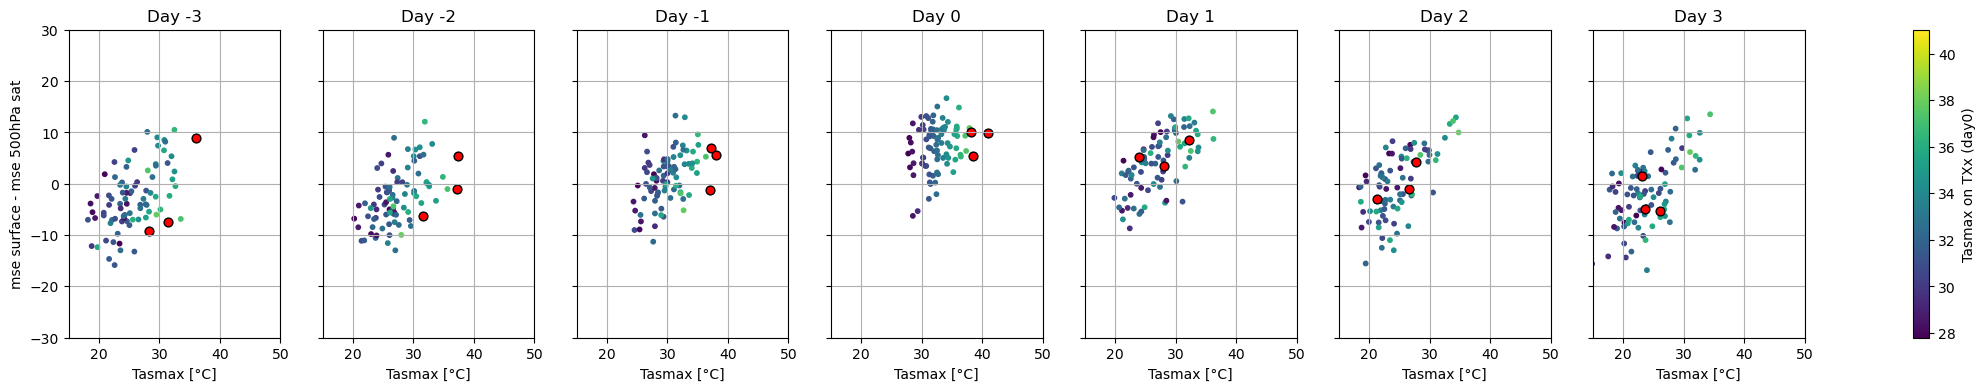

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15      # dims: composite_year, time, lat, lon
mse = ds["mse"]                      # dims: composite_year, time, lat, lon, lev
mse_sat = ds["mse_sat"]              # dims: composite_year, time, lat, lon

# Compute mse - mse_sat
mse_diff = mse - mse_sat

# Flatten all spatial dims
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))  # composite_year, time, space

tas_flat = flatten(tasmax)
mse_diff_flat = flatten(mse_diff)

# Color based on day0 Tasmax
c = tas_flat[:, 3, :].ravel()  # day0 = index 3
c_min, c_max = c.min(), c.max()

# Identify the 5 hottest day0 points
top5_idx = np.argsort(c)[-3:]

# Create figure with 7 subplots
fig, axes = plt.subplots(1, 7, figsize=(28, 4), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    x = tas_flat[:, i, :].ravel()        # Tasmax at current day
    y = mse_diff_flat[:, i, :].ravel()  # mse - mse_sat at current day

    # Scatter for all points
    sc = ax.scatter(
        x, y,
        c=c,           # color = TXx day Tasmax
        vmin=c_min,
        vmax=c_max,
        s=10,
        alpha=1.0
    )

    # Highlight top5 hottest day0 points in red
    ax.scatter(
        x.ravel()[top5_idx],
        y.ravel()[top5_idx],
        color='red',
        edgecolor='black',
        s=40,
        label='Top 5 hottest day0'
    )

    ax.set_title(f"Day {i-3}")
    ax.set_xlabel("Tasmax [°C]")
    ax.set_xlim(15, 50)
    ax.set_ylim(-30, 30)
    ax.grid()
    if i == 0:
        ax.set_ylabel("mse surface - mse 500hPa sat")

# Shared colorbar
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical')
cbar.set_label("Tasmax on TXx (day0)")

#plt.tight_layout()
plt.savefig('composite_tasmax_mse_era5.pdf')
plt.show()


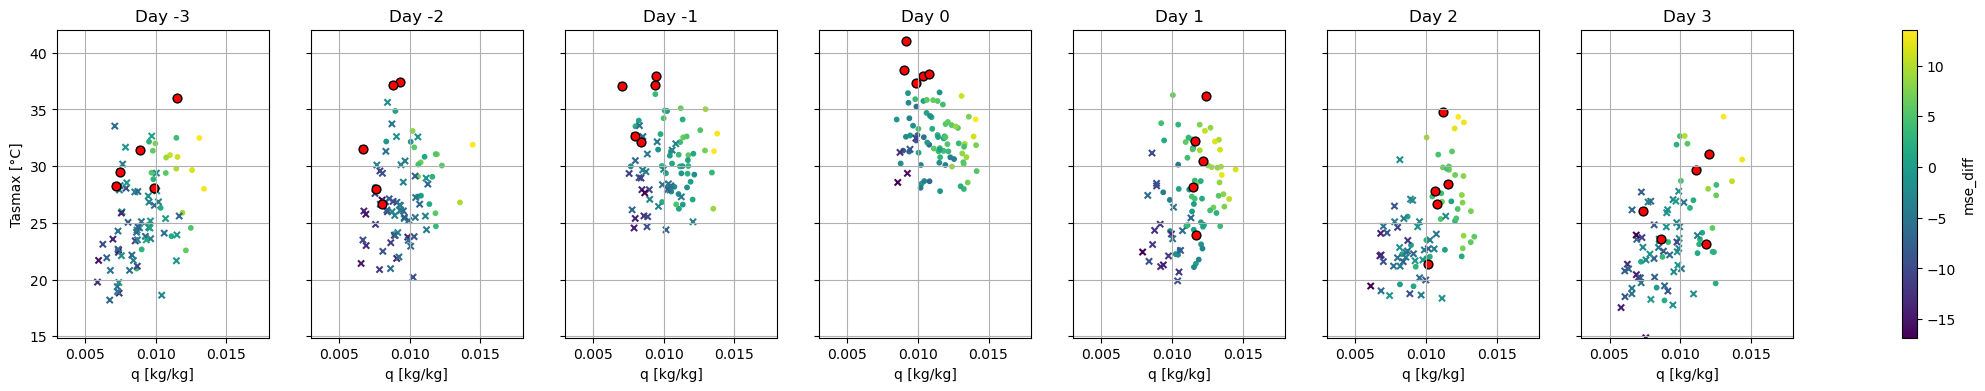

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15
q = ds["q"]
mse = ds["mse"]
mse_sat = ds["mse_sat"]

# Select single level if needed
if 'lev' in q.dims:
    q = q.isel(lev=0)

# Flatten function
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_diff_flat = flatten(mse - mse_sat)

# Top 5 day0 hottest points
c_day0 = tas_flat[:, 3, :].ravel()
top5_idx = np.argsort(c_day0)[-5:]

# Create plot
fig, axes = plt.subplots(1, 7, figsize=(28, 4), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    x = q_flat[:, i, :].ravel()                       # Specific humidity
    y = tas_flat[:, i, :].ravel()                     # Tasmax
    c = mse_diff_flat[:, i, :].ravel()                # mse_diff as color

    # Split into positive and negative mse_diff
    pos = c >= 0
    neg = c < 0

    c_min, c_max = c.min(), c.max()

    # Plot positive values as dots
    sc = ax.scatter(
        x[pos], y[pos],
        c=c[pos],
        vmin=c_min, vmax=c_max,
        s=10, alpha=1.0,
        marker="o"
    )

    # Plot negative values as crosses
    ax.scatter(
        x[neg], y[neg],
        c=c[neg],
        vmin=c_min, vmax=c_max,
        s=20, alpha=1.0,
        marker="x"
    )

    # Highlight the hottest day0 points
    ax.scatter(
        x[top5_idx], y[top5_idx],
        color='red',
        edgecolor='black',
        s=40,
        label='Top 5 hottest day0'
    )

    ax.set_title(f"Day {i-3}")
    ax.set_xlabel("q [kg/kg]")
    ax.set_xlim(0.003, 0.018)
    ax.set_ylim(tas_flat.min(), tas_flat.max()+1)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Tasmax [°C]")

# Shared colorbar
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical')
cbar.set_label("mse_diff")

plt.savefig("composite_q_mse_marker_split.pdf")
plt.show()


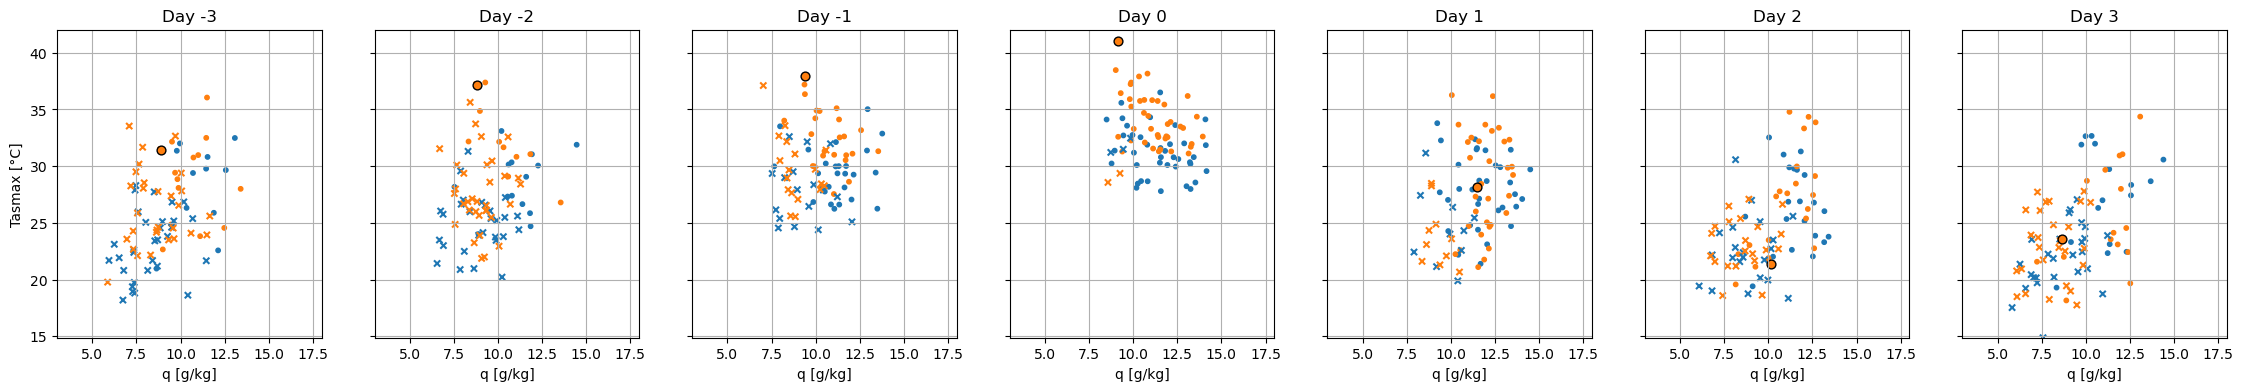

In [28]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15
q = ds["q"]*1e3
mse = ds["mse"]
mse_sat = ds["mse_sat"]

# Select single level if needed
if 'lev' in q.dims:
    q = q.isel(lev=0)

# Flatten function
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_diff_flat = flatten(mse - mse_sat)

# ---- NEW: split along time axis ----
ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half     # first half of time axis
groupB = np.arange(ntime) >= half    # second half of time axis

# For indexing the flattened arrays (time, day, space)
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()
groupB_idx = ~groupA_idx

# Top 5 day0 hottest points
c_day0 = tas_flat[:, 3, :].ravel()
top5_idx = np.argsort(c_day0)[-1:]

# Create plot
fig, axes = plt.subplots(1, 7, figsize=(28, 4), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    x = q_flat[:, i, :].ravel()      # Specific humidity
    y = tas_flat[:, i, :].ravel()    # Tasmax
    c = mse_diff_flat[:, i, :].ravel()

    pos = c >= 0
    neg = c < 0

    # ---- NEW COLOR LOGIC ----
    # group A = blue, group B = orange
    colors = np.where(groupA_idx, "tab:blue", "tab:orange")

    # Positive mse_diff = dots
    ax.scatter(
        x[pos], y[pos],
        c=colors[pos],
        s=10, alpha=1.0,
        marker="o"
    )

    # Negative mse_diff = crosses
    ax.scatter(
        x[neg], y[neg],
        c=colors[neg],
        s=20, alpha=1.0,
        marker="x"
    )

    # Highlight top 5 day0 hottest points
    ax.scatter(
        x[top5_idx], y[top5_idx],
        color=colors[top5_idx],
        edgecolor='black',
        s=40,
        label='Top 3 hottest day0'
    )

    ax.set_title(f"Day {i-3}")
    ax.set_xlabel("q [g/kg]")
    ax.set_xlim(0.003*1e3, 0.018*1e3)
    ax.set_ylim(tas_flat.min(), tas_flat.max() + 1)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Tasmax [°C]")

plt.savefig("composite_q_split_groups_marker.pdf")
plt.show()


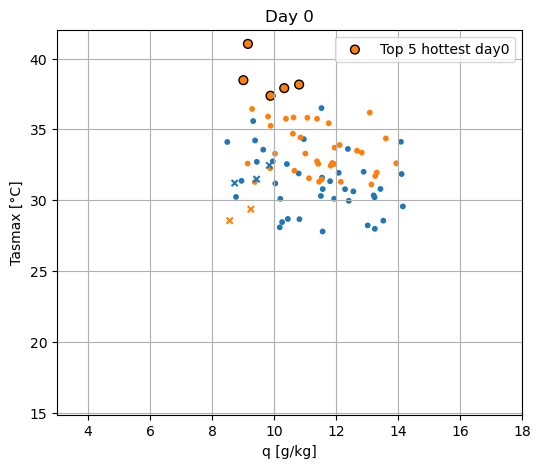

In [48]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15
q = ds["q"] * 1e3
mse = ds["mse"]
mse_sat = ds["mse_sat"]

# Select single level if needed
if 'lev' in q.dims:
    q = q.isel(lev=0)

# Flatten function
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_diff_flat = flatten(mse - mse_sat)

# ---- NEW: split along time axis ----
ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half     # first half of time axis
groupB = np.arange(ntime) >= half    # second half of time axis

# For indexing the flattened arrays (time, day, space)
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Top 5 day0 hottest points
day0_idx = 3  # Day 0 index in your array
c_day0 = tas_flat[:, day0_idx, :].ravel()
top5_idx = np.argsort(c_day0)[-5:]  # top 5 hottest points

# Extract data for Day 0
x = q_flat[:, day0_idx, :].ravel()
y = tas_flat[:, day0_idx, :].ravel()
c = mse_diff_flat[:, day0_idx, :].ravel()

pos = c >= 0
neg = c < 0

colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# Create the figure
fig, ax = plt.subplots(figsize=(6, 5))

# Positive mse_diff = dots
ax.scatter(x[pos], y[pos], c=colors[pos], s=10, alpha=1.0, marker="o")

# Negative mse_diff = crosses
ax.scatter(x[neg], y[neg], c=colors[neg], s=20, alpha=1.0, marker="x")

# Highlight top 5 day0 hottest points
ax.scatter(x[top5_idx], y[top5_idx], color=colors[top5_idx],
           edgecolor='black', s=40, label='Top 5 hottest day0')

ax.set_title("Day 0")
ax.set_xlabel("q [g/kg]")
ax.set_ylabel("Tasmax [°C]")
ax.set_xlim(0.003*1e3, 0.018*1e3)
ax.set_ylim(tas_flat.min(), tas_flat.max() + 1)
ax.grid()
ax.legend()

plt.savefig("composite_q_day0.pdf")
plt.show()


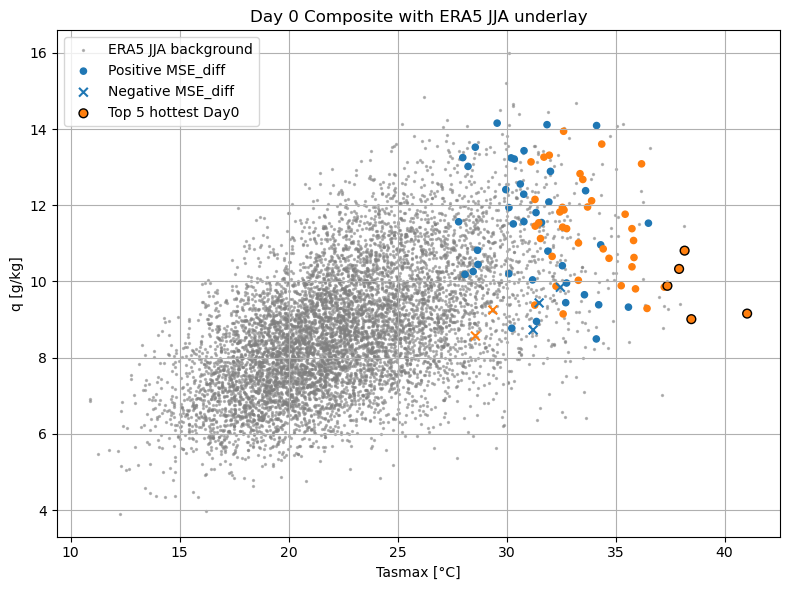

In [26]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["mse"]
mse_sat_era = jja["mse_sat"]
q_era = jja["q"]* 1e3
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = q_era.values.ravel()
y_era = tasmax_era.values.ravel()
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["q"] * 1e3
mse = ds["mse"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = q_flat[:, day0_idx, :].ravel()
y = tas_flat[:, day0_idx, :].ravel()
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

top5_idx = np.argsort(y)[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Plot
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Grey underlay: ERA5 JJA
ax.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')

# Composite Day 0 scatter
ax.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='Positive MSE_diff')
ax.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='x', label='Negative MSE_diff')

# Highlight top 5 hottest Day 0 points
ax.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx], edgecolor='black', s=40, label='Top 5 hottest Day0')

ax.set_xlabel("Tasmax [°C]")
ax.set_ylabel("q [g/kg]")
#ax.set_xlim(0.003*1e3, 0.018*1e3)
#ax.set_ylim(x.min(), x.max() + 1)
ax.set_title("Day 0 Composite with ERA5 JJA underlay")
ax.grid()
ax.legend()

plt.tight_layout()
plt.savefig("composite_day0_with_ERA5_underlay.pdf")
plt.show()


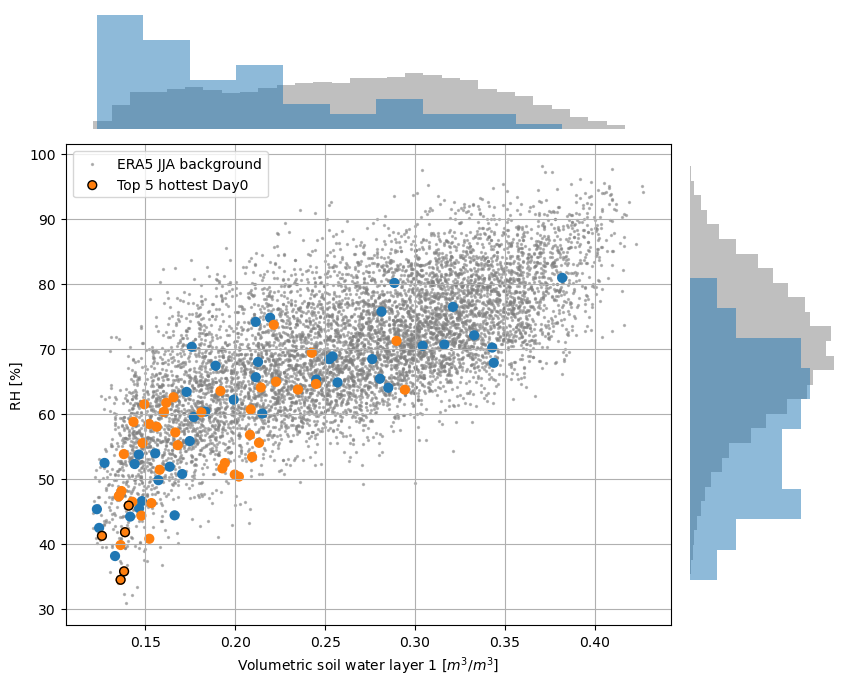

In [40]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja["swvl1"]
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["swvl1"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Volumetric soil water layer 1 [$m^3/m^3$]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("rh_swvl_composite_day0_q_axis.pdf")
plt.show()


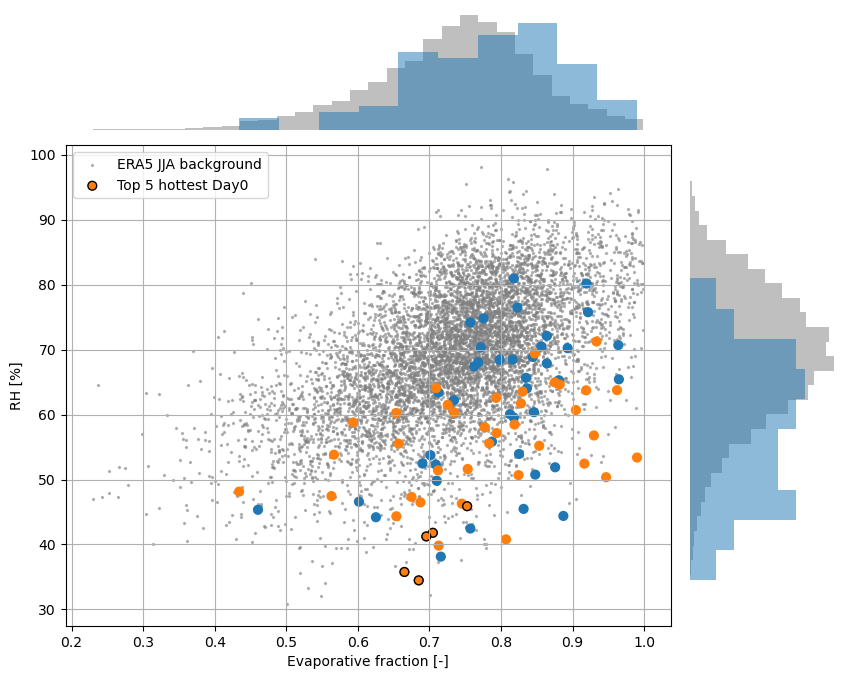

In [6]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja["EF"]
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["EF"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Evaporative fraction [-]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#ax_scatter.set_xlim(0,1)

#plt.tight_layout()
plt.savefig("rh_EF_composite_day0_q_axis.pdf")
plt.show()


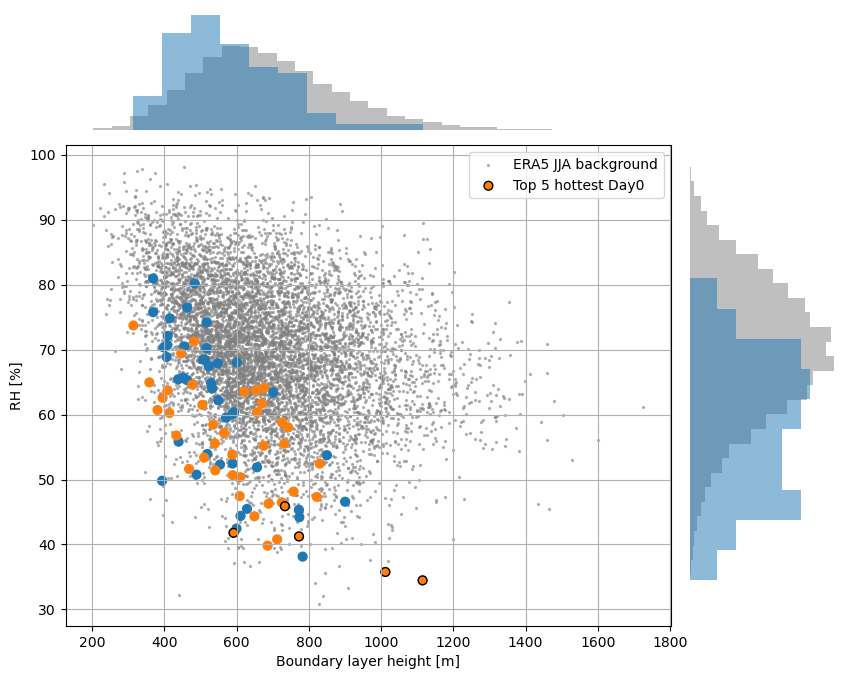

In [8]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja['blh']
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["blh"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Boundary layer height [m]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks


#plt.tight_layout()
plt.savefig("rh_blh_composite_day0_q_axis.pdf")
plt.show()


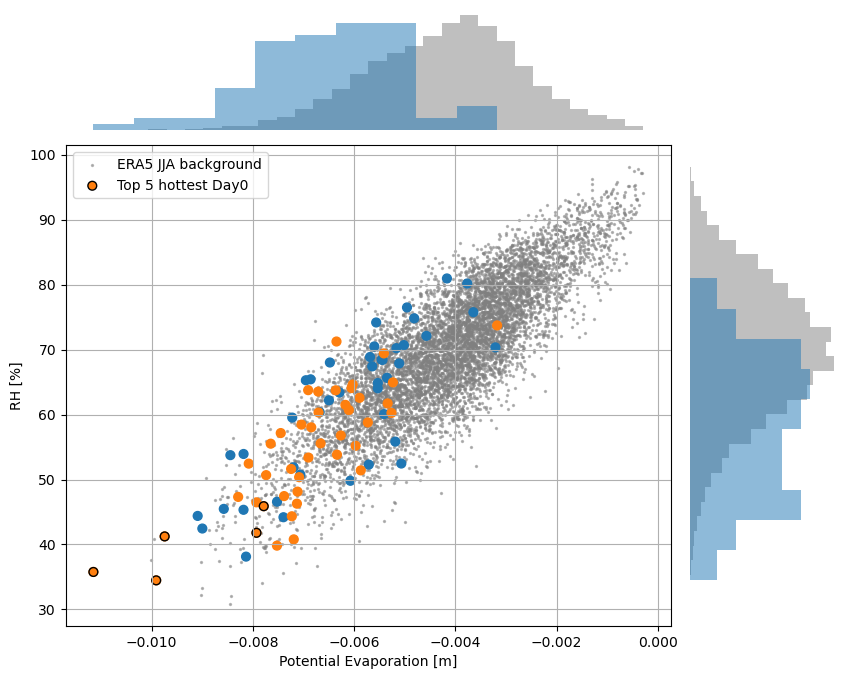

In [7]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja['pev']
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["pev"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Potential Evaporation [m]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks


#plt.tight_layout()
plt.savefig("rh_cape_composite_day0_q_axis.pdf")
plt.show()


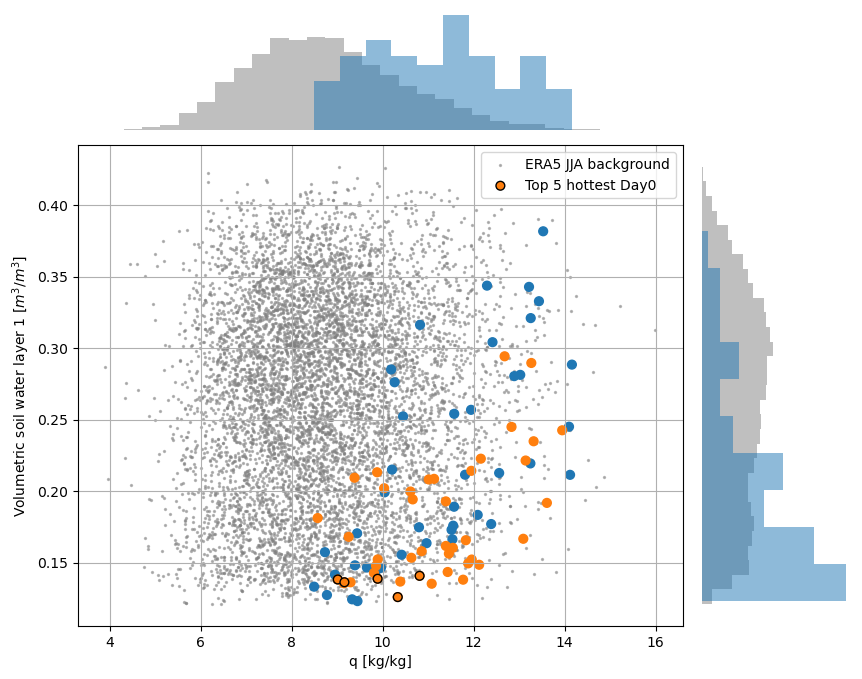

In [41]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["swvl1"]
mse_sat_era = jja["mse_sat"]
q_era = jja["q"]*1e3
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["q"]*1e3 
mse = ds["swvl1"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("q [kg/kg]")
ax_scatter.set_ylabel("Volumetric soil water layer 1 [$m^3/m^3$]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("q_swvl_composite_day0_q_axis.pdf")
plt.show()


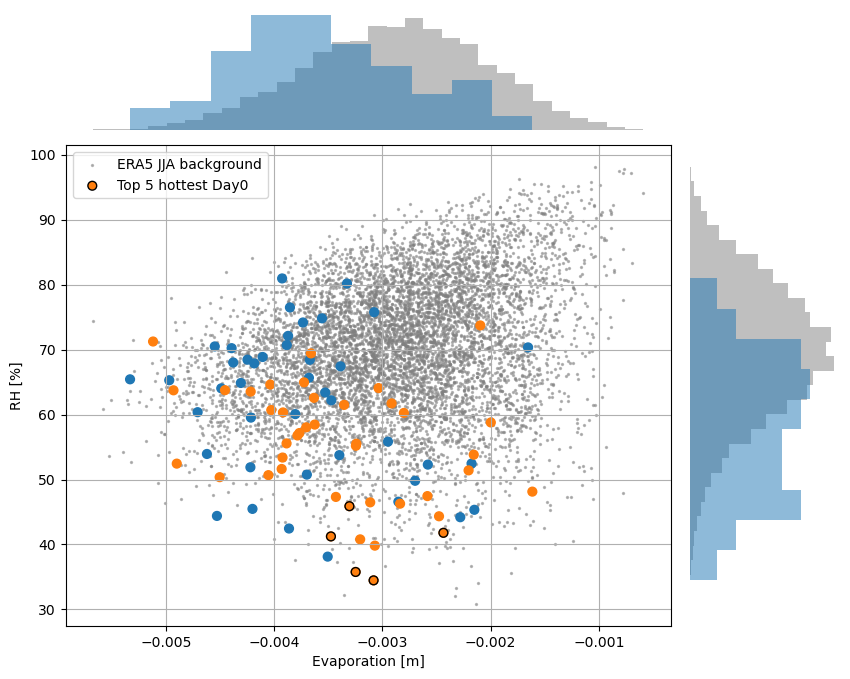

In [9]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja['e']
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["e"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Evaporation [m]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks


#plt.tight_layout()
plt.savefig("rh_e_composite_day0_q_axis.pdf")
plt.show()


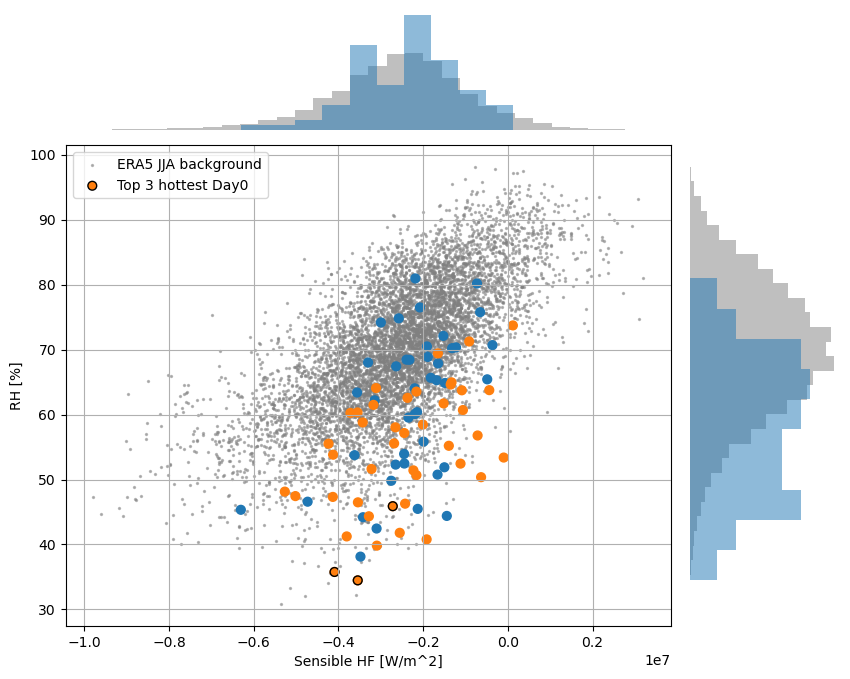

In [14]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja['sshf']
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["sshf"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-3:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 3 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Sensible HF [W/m^2]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks


#plt.tight_layout()
plt.savefig("rh_sshf_composite_day0_q_axis.pdf")
plt.show()


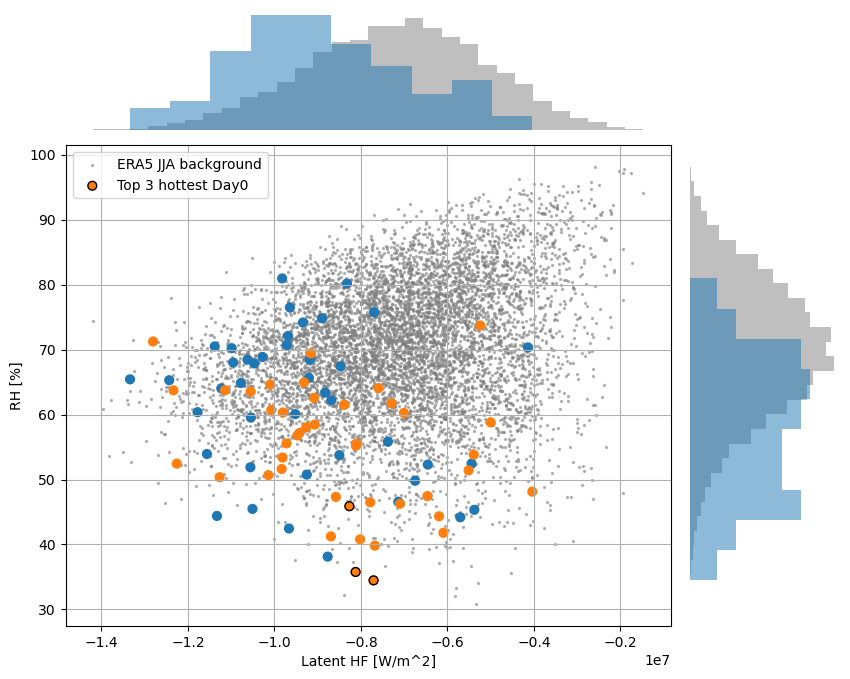

In [15]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja['slhf']
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["slhf"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-3:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 3 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("Latent HF [W/m^2]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks


#plt.tight_layout()
plt.savefig("rh_slhf_composite_day0_q_axis.pdf")
plt.show()


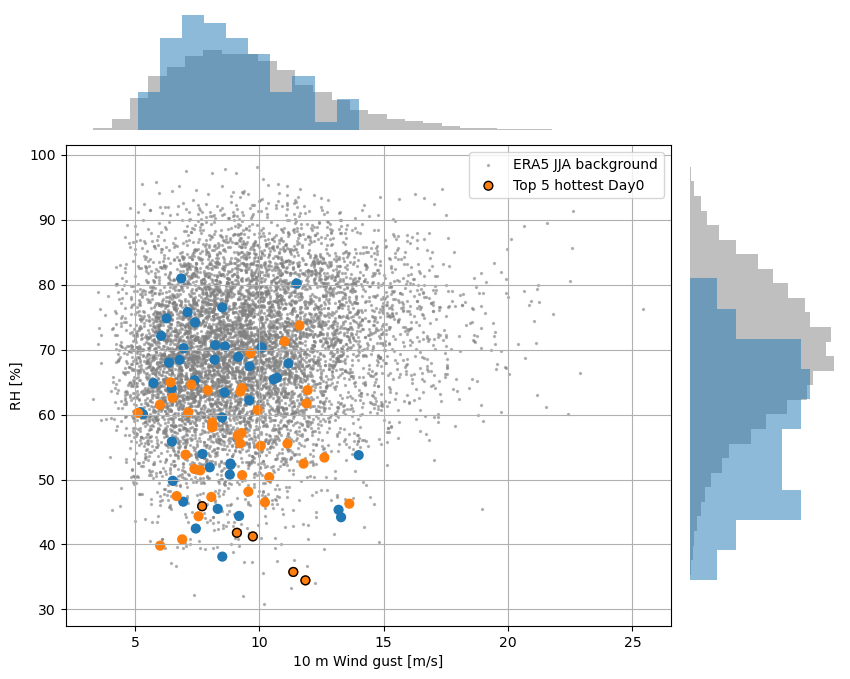

In [9]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja['10fg']
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["10fg"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("10 m Wind gust [m/s]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks


#plt.tight_layout()
plt.savefig("rh_10fg_composite_day0_q_axis.pdf")
plt.show()


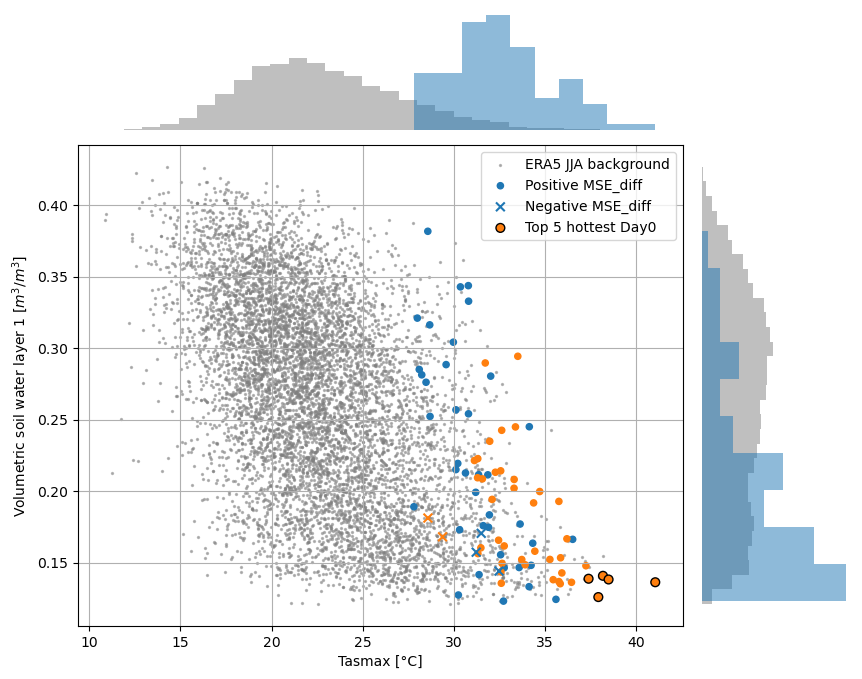

In [23]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["mse"]
mse_sat_era = jja["mse_sat"]
q_era = jja["swvl1"]
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = q_era.values.ravel()
y_era = tasmax_era.values.ravel()
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["swvl1"] 
mse = ds["mse"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
mse_sat_flat = flatten(mse_sat)
q_flat = flatten(q)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = q_flat[:, day0_idx, :].ravel()
y = tas_flat[:, day0_idx, :].ravel()
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

top5_idx = np.argsort(y)[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")


# -------------------------------------------------------------
# 1. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 2. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='Positive MSE_diff')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='x', label='Negative MSE_diff')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("Tasmax [°C]")
ax_scatter.set_ylabel(r"Volumetric soil water layer 1 [$m^3/m^3$]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 3. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("swvl1_composite_day0_with_marginals.pdf")
plt.show()


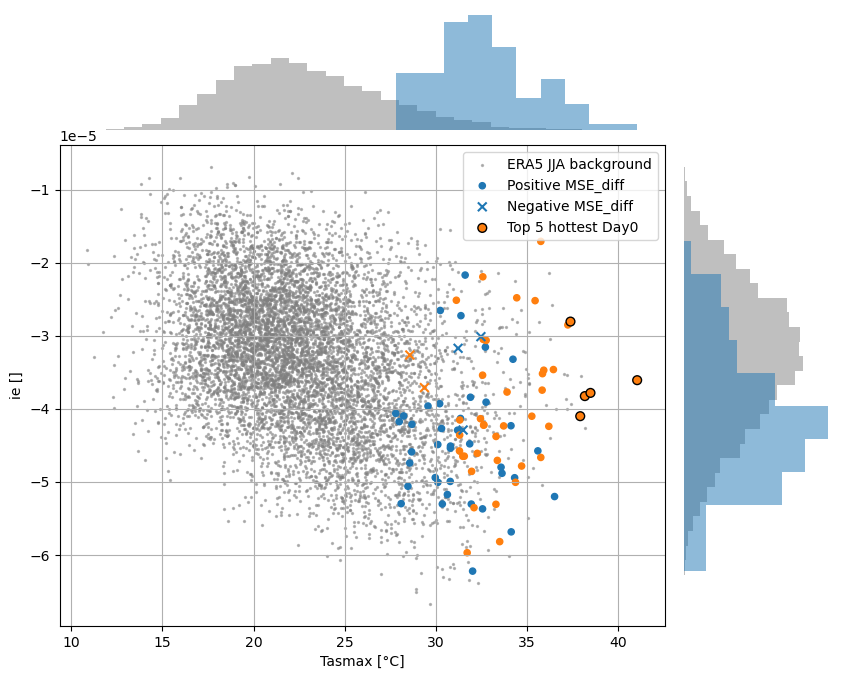

In [22]:
### import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["mse"]
mse_sat_era = jja["mse_sat"]
q_era = jja["ie"]
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = q_era.values.ravel()
y_era = tasmax_era.values.ravel()
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["ie"] 
mse = ds["mse"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
mse_sat_flat = flatten(mse_sat)
q_flat = flatten(q)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = q_flat[:, day0_idx, :].ravel()
y = tas_flat[:, day0_idx, :].ravel()
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

top5_idx = np.argsort(y)[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")


# -------------------------------------------------------------
# 1. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 2. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='Positive MSE_diff')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='x', label='Negative MSE_diff')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("Tasmax [°C]")
ax_scatter.set_ylabel(r"ie [$kg/(m^2/s]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 3. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("ie_composite_day0_with_marginals.pdf")
plt.show()


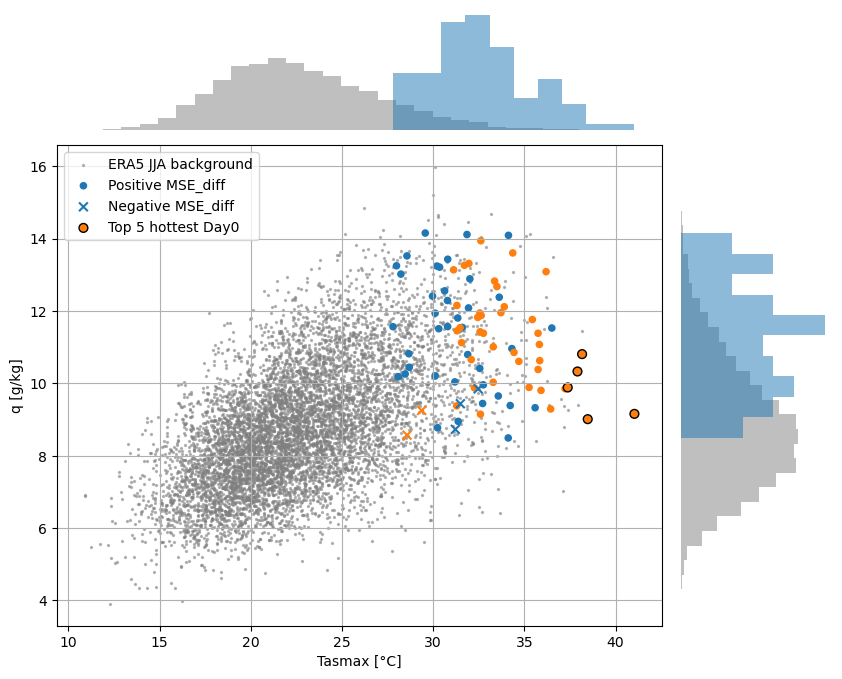

In [62]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------------------------------------------
# 1. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 2. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='Positive MSE_diff')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='x', label='Negative MSE_diff')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("Tasmax [°C]")
ax_scatter.set_ylabel("q [g/kg]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 3. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("composite_day0_with_marginals.pdf")
plt.show()


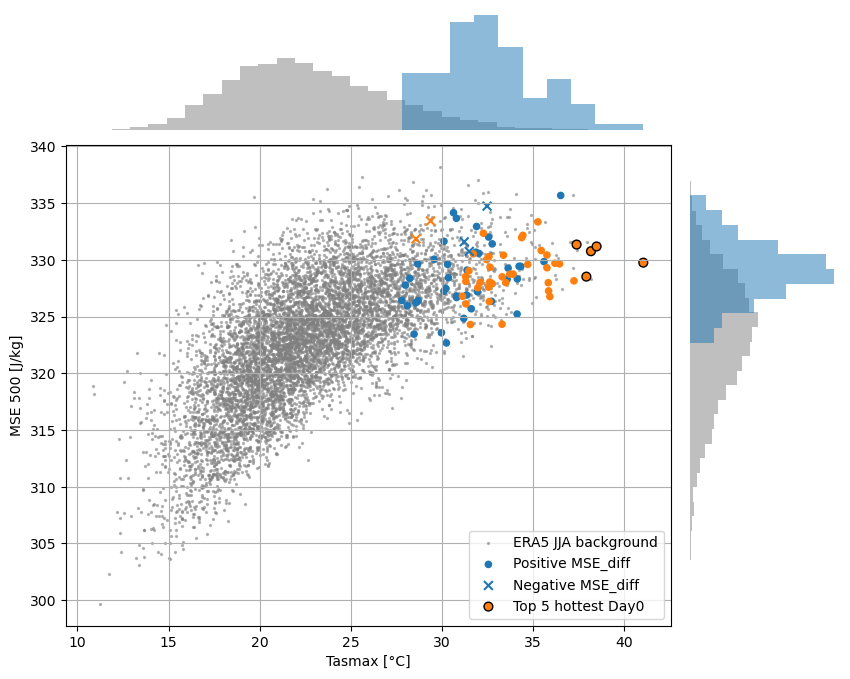

In [71]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
ds_era = xr.open_dataset("/work/uc1275/u301827/02_MSE/paris/era5_mse_full_1940_2024.nc")
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["mse"]
mse_sat_era = jja["mse_sat"]
q_era = jja["q"]* 1e3
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_sat_era.values.ravel()
y_era = tasmax_era.values.ravel()
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["q"] * 1e3
mse = ds["mse"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
mse_sat_flat = flatten(mse_sat)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_sat_flat[:, day0_idx, :].ravel()
y = tas_flat[:, day0_idx, :].ravel()
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

top5_idx = np.argsort(y)[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")


# -------------------------------------------------------------
# 1. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 2. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='Positive MSE_diff')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='x', label='Negative MSE_diff')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("Tasmax [°C]")
ax_scatter.set_ylabel("MSE 500 [J/kg]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 3. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("mse_sat_composite_day0_with_marginals.pdf")
plt.show()


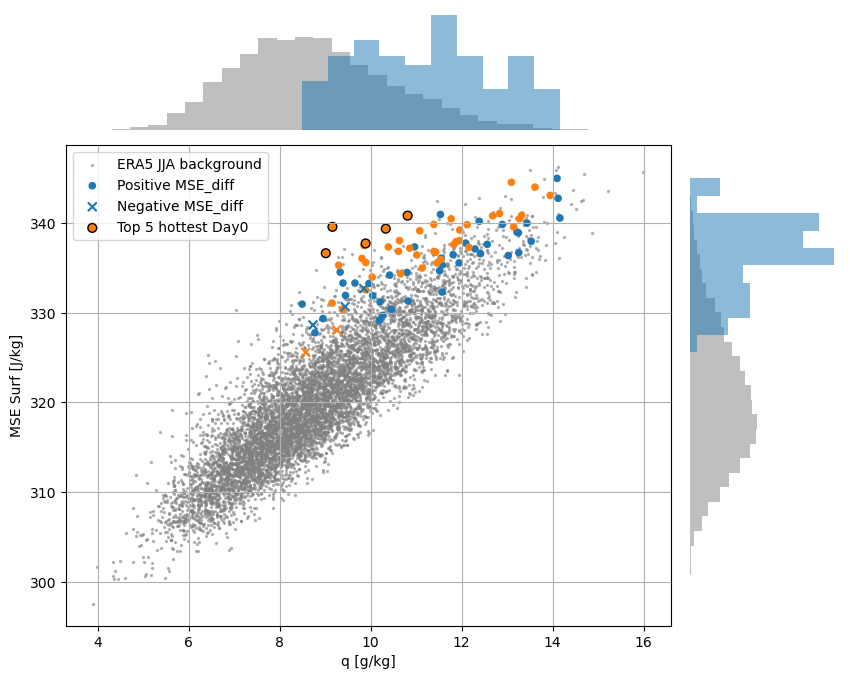

In [75]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
ds_era = xr.open_dataset("/work/uc1275/u301827/02_MSE/paris/era5_mse_full_1940_2024.nc")
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["mse"]
mse_sat_era = jja["mse_sat"]
q_era = jja["q"]* 1e3
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["q"] * 1e3
mse = ds["mse"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='Positive MSE_diff')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='x', label='Negative MSE_diff')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("q [g/kg]")
ax_scatter.set_ylabel("MSE Surf [J/kg]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("mse_surf_composite_day0_q_axis.pdf")
plt.show()


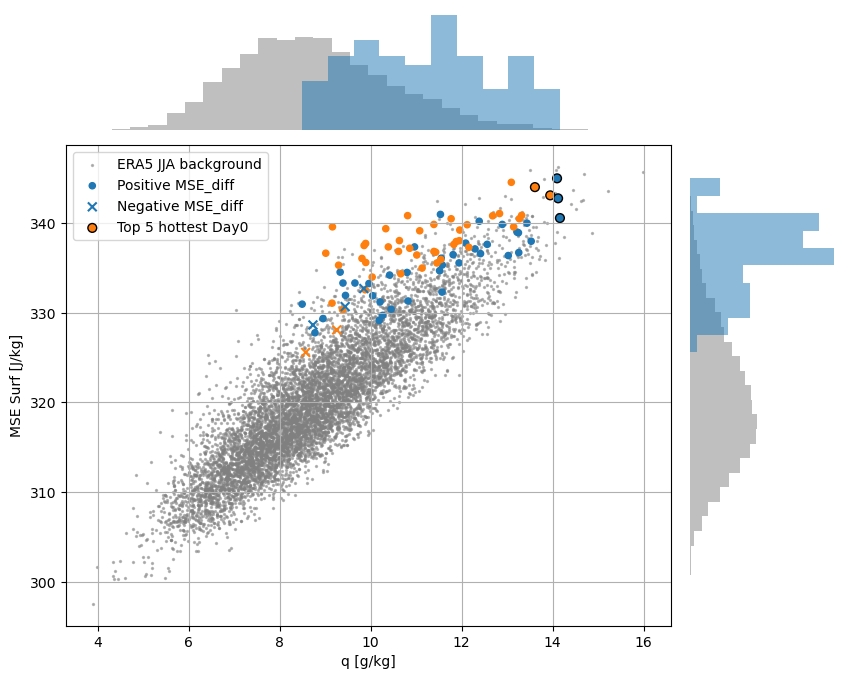

In [73]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
ds_era = xr.open_dataset("/work/uc1275/u301827/02_MSE/paris/era5_mse_full_1940_2024.nc")
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["mse"]
mse_sat_era = jja["mse_sat"]
q_era = jja["q"]* 1e3
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()
y_era = q_era.values.ravel()
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["q"] * 1e3
mse = ds["mse"]
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()
y = tas_flat[:, day0_idx, :].ravel()
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

top5_idx = np.argsort(y)[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")


# -------------------------------------------------------------
# 1. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 2. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='Positive MSE_diff')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='x', label='Negative MSE_diff')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_xlabel("q [g/kg]")
ax_scatter.set_ylabel("MSE Surf [J/kg]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 3. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

#plt.tight_layout()
plt.savefig("mse_surf_q_composite_day0_with_marginals.pdf")
plt.show()


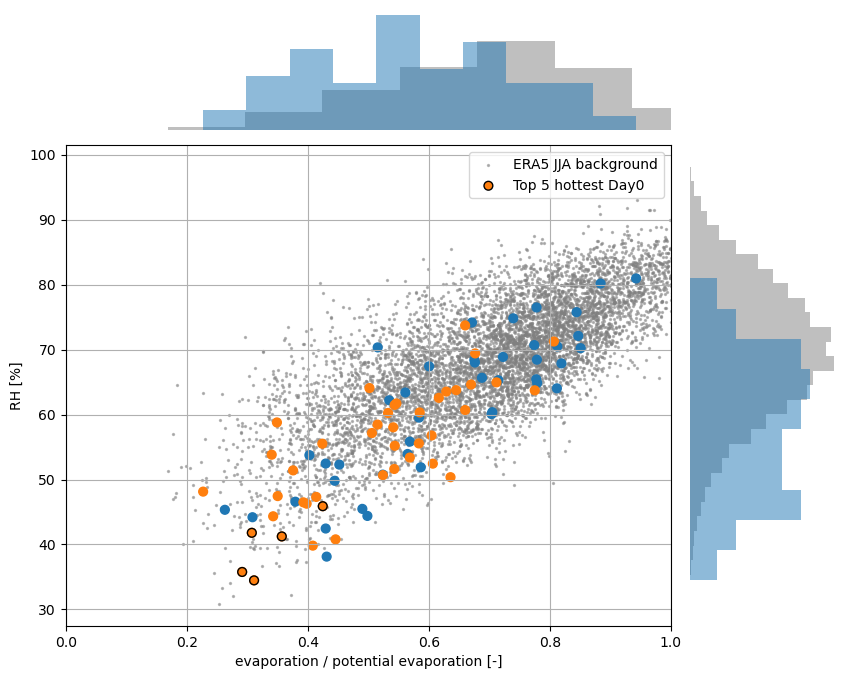

In [14]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import xarray as xr

# -------------------------------------------------------------
# 1. Load ERA5 dataset (grey underlay)
# -------------------------------------------------------------
jja = ds_era.sel(time=ds_era.time.dt.month.isin([6, 7, 8]))

mse_era = jja["rh"]*100
mse_sat_era = jja["mse_sat"]
q_era = jja["evf"]
tasmax_era = jja["tasmax"] - 273.15

mse_diff_era = mse_era - mse_sat_era

# Flatten
x_era = mse_era.values.ravel()      # Y-axis: MSE
y_era = q_era.values.ravel()        # X-axis: q
c_era = mse_diff_era.values.ravel()

mask = ~np.isnan(x_era) & ~np.isnan(y_era) & ~np.isnan(c_era)
x_era = x_era[mask]
y_era = y_era[mask]
c_era = c_era[mask]

# -------------------------------------------------------------
# 2. Load Day 0 composite data
# -------------------------------------------------------------
ds = composite_ds
tasmax = ds["tasmax"] - 273.15
q = ds["evf"] 
mse = ds["rh"]*100
mse_sat = ds["mse_sat"]

if 'lev' in q.dims:
    q = q.isel(lev=0)

def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_flat = flatten(mse)
mse_diff_flat = flatten(mse - mse_sat)

ntime = tas_flat.shape[0]
half = ntime // 2
groupA = np.arange(ntime) < half
groupA_idx = np.repeat(groupA[:, None], tas_flat.shape[2], axis=1).ravel()

# Day 0
day0_idx = 3
x = mse_flat[:, day0_idx, :].ravel()    # Y-axis: MSE
y = q_flat[:, day0_idx, :].ravel()      # X-axis: q
c = mse_diff_flat[:, day0_idx, :].ravel()
pos = c >= 0
neg = c < 0

# Hottest 5 extremes based on Tasmax at Day0
top5_idx = np.argsort(tas_flat[:, day0_idx, :].mean(axis=1))[-5:]
colors = np.where(groupA_idx, "tab:blue", "tab:orange")

# -------------------------------------------------------------
# 3. Create figure with scatter + marginal histograms
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
              wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
# X-axis histogram
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
# Y-axis histogram
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# -------------------------------------------------------------
# 4. Scatter plot
# -------------------------------------------------------------
ax_scatter.scatter(y_era, x_era, c='grey', s=2, alpha=0.5, label='ERA5 JJA background')
ax_scatter.scatter(y[pos], x[pos], c=colors[pos], s=20, marker='o', label='')
ax_scatter.scatter(y[neg], x[neg], c=colors[neg], s=40, marker='o', label='')
ax_scatter.scatter(y[top5_idx], x[top5_idx], color=colors[top5_idx],
                   edgecolor='black', s=40, label='Top 5 hottest Day0')

ax_scatter.set_ylabel("RH [%]")
ax_scatter.set_xlabel("evaporation / potential evaporation [-]")
ax_scatter.grid()
ax_scatter.legend()

# -------------------------------------------------------------
# 5. Marginal histograms
# -------------------------------------------------------------
bins_x = 30
bins_y = 30

# X-axis histograms
ax_histx.hist(y_era, bins=bins_x, color='grey', alpha=0.5, density=True)
ax_histx.hist(y, bins=10, color='tab:blue', alpha=0.5, density=True)
ax_histx.axis('off')  # remove ticks

# Y-axis histograms
ax_histy.hist(x_era, bins=bins_y, color='grey', alpha=0.5, density=True, orientation='horizontal')
ax_histy.hist(x, bins=10, color='tab:blue', alpha=0.5, density=True, orientation='horizontal')
ax_histy.axis('off')  # remove ticks

ax_scatter.set_xlim(0,1)

#plt.tight_layout()
plt.savefig("rh_EvF_composite_day0_q_axis.pdf")
plt.show()


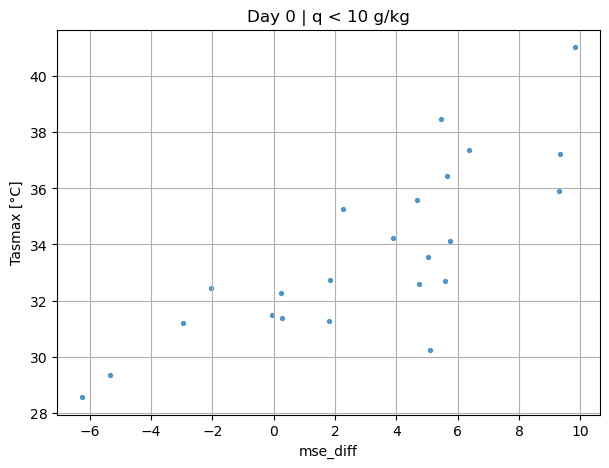

In [27]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15
q = ds["q"] * 1e3              # convert to g/kg
mse = ds["mse"]
mse_sat = ds["mse_sat"]

# Select single level if needed
if "lev" in q.dims:
    q = q.isel(lev=0)

# Flatten helper
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_sat_flat = flatten(mse - mse_sat)

# ---- DAY 0 (index = 3) ----
q_vals = q_flat[:, 3, :].ravel()
tas_vals = tas_flat[:, 3, :].ravel()
mse_sat_vals = mse_sat_flat[:, 3, :].ravel()

# ---- Filter q < 10 g/kg ----
mask = q_vals < 10.0
q_vals = q_vals[mask]
tas_vals = tas_vals[mask]
mse_sat_vals = mse_sat_vals[mask]

# ---- Scatter Plot ----
plt.figure(figsize=(7, 5))
plt.scatter(mse_sat_vals, tas_vals, s=8, alpha=0.7)

plt.xlabel("mse_diff")
plt.ylabel("Tasmax [°C]")
plt.title("Day 0 | q < 10 g/kg")
plt.grid(True)

plt.savefig("tas_vs_mse_sat_day0_q<10.png", dpi=150)
plt.show()


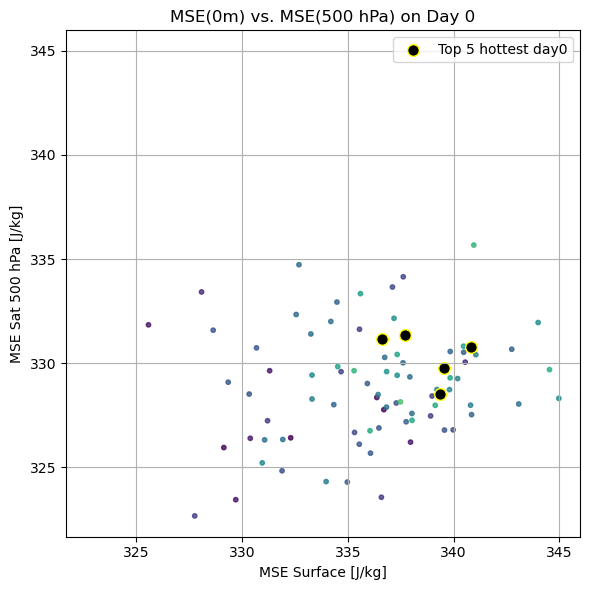

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15
mse_sfc = ds["mse"]        # surface MSE
mse_500 = ds["mse_sat"]    # MSE at 500 hPa (already computed)

# Flatten helper
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))

# Flatten all fields
mse_sfc_flat = flatten(mse_sfc)
mse_500_flat = flatten(mse_500)
tas_flat = flatten(tasmax)

# Color by day0 tasmax
c = tas_flat[:, 3, :].ravel()
top5_idx = np.argsort(c)[-5:]

# Day 0 values
x = mse_sfc_flat[:, 3, :].ravel()
y = mse_500_flat[:, 3, :].ravel()

# === Set equal axis limits ===
xy_min = min(x.min(), y.min())
xy_max = max(x.max(), y.max())

# --- Scatter plot ---
plt.figure(figsize=(6, 6))

sc = plt.scatter(x, y, c=c, cmap="viridis", s=10, alpha=0.8)

# Highlight top-5 hottest events
plt.scatter(
    x[top5_idx], y[top5_idx],
    color="black",
    edgecolor="yellow",
    s=70, marker="o",
    label="Top 5 hottest day0"
)

plt.xlabel("MSE Surface [J/kg]")
plt.ylabel("MSE Sat 500 hPa [J/kg]")
plt.title("MSE(0m) vs. MSE(500 hPa) on Day 0")

plt.xlim(xy_min-1, xy_max+1)
plt.ylim(xy_min-1, xy_max+1)

plt.grid(True)


plt.legend()
plt.tight_layout()
plt.show()


next: do composite plot of 3 days before to 3 days after of all TXx (mean and percentiles) and plot the 3 hottest day 0s in color. plot tasmax, q and delta mse.

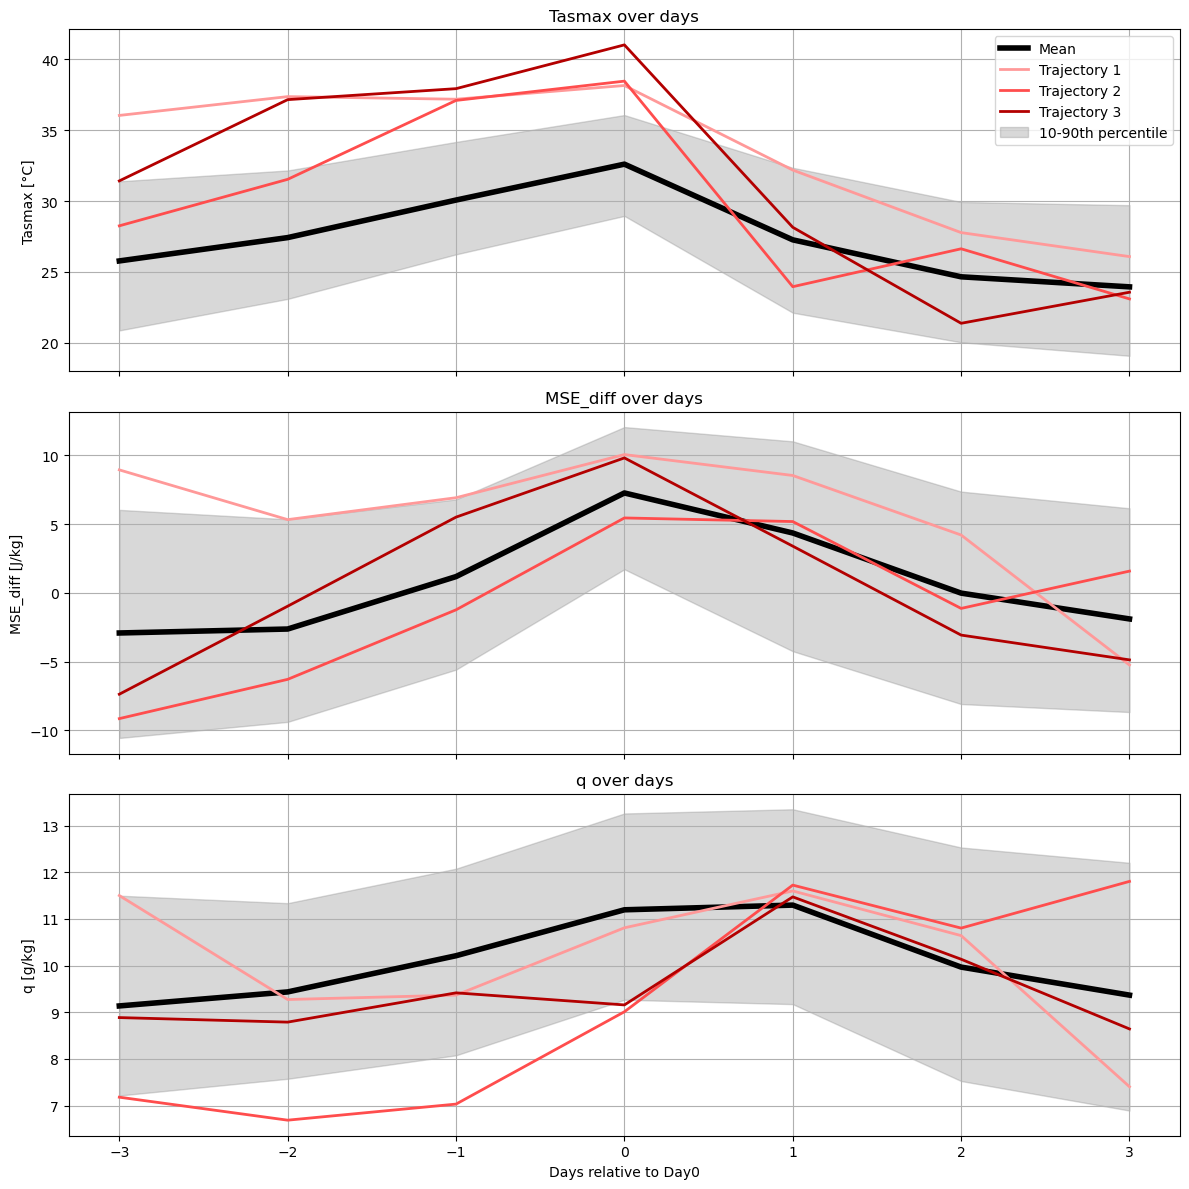

In [68]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15   # dims: composite_year, time, lat, lon
mse = ds["mse"]                  # dims: composite_year, time, lat, lon
mse_sat = ds["mse_sat"]          # dims: composite_year, time, lat, lon
q = ds["q"] * 1e3                # g/kg

# Flatten all spatial dims
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))  # composite_year, time, space

tas_flat = flatten(tasmax)
mse_diff_flat = flatten(mse - mse_sat)
q_flat = flatten(q)

# Select 3 hottest Day0 trajectories
day0 = 3
tas_day0 = tas_flat[:, day0, :]
top3_idx = np.argsort(tas_day0.mean(axis=1))[-3:]  # top 3 hottest trajectories

# Compute percentiles and mean across composites & space
tas_p10_time = np.nanpercentile(tas_flat, 10, axis=(0,2))
tas_p90_time = np.nanpercentile(tas_flat, 90, axis=(0,2))
tas_mean_time = np.nanmean(tas_flat, axis=(0,2))

mse_diff_p10_time = np.nanpercentile(mse_diff_flat, 10, axis=(0,2))
mse_diff_p90_time = np.nanpercentile(mse_diff_flat, 90, axis=(0,2))
mse_diff_mean_time = np.nanmean(mse_diff_flat, axis=(0,2))

q_p10_time = np.nanpercentile(q_flat, 10, axis=(0,2))
q_p90_time = np.nanpercentile(q_flat, 90, axis=(0,2))
q_mean_time = np.nanmean(q_flat, axis=(0,2))

days = np.arange(tas_flat.shape[1]) - day0  # centered on Day0

# Shades of red for top 3 trajectories
colors_red = ["#ff9999", "#ff4d4d", "#b30000"]

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# ----------------------------
# Top panel: Tasmax
# ----------------------------
ax = axes[0]
ax.fill_between(days, tas_p10_time, tas_p90_time, color='grey', alpha=0.3, label='10-90th percentile')
ax.plot(days, tas_mean_time,  color='black', lw=4, label='Mean')
for i, idx in enumerate(top3_idx):
    ax.plot(days, tas_flat[idx, :, :].mean(axis=1), lw=2, color=colors_red[i], label=f'Trajectory {i+1}')
ax.set_ylabel('Tasmax [°C]')
ax.set_title('Tasmax over days')
ax.grid()
ax.legend()

# ----------------------------
# Middle panel: MSE_diff
# ----------------------------
ax = axes[1]
ax.fill_between(days, mse_diff_p10_time, mse_diff_p90_time, color='grey', alpha=0.3, label='10-90th percentile')
ax.plot(days, mse_diff_mean_time,  color='black', lw=4, label='Mean')
for i, idx in enumerate(top3_idx):
    ax.plot(days, mse_diff_flat[idx, :, :].mean(axis=1), lw=2, color=colors_red[i], label=f'Trajectory {i+1}')
ax.set_ylabel('MSE_diff [J/kg]')
ax.set_title('MSE_diff over days')
ax.grid()

# ----------------------------
# Bottom panel: q
# ----------------------------
ax = axes[2]
ax.fill_between(days, q_p10_time, q_p90_time, color='grey', alpha=0.3, label='10-90th percentile')
ax.plot(days, q_mean_time, color='black', lw=4, label='Mean')
for i, idx in enumerate(top3_idx):
    ax.plot(days, q_flat[idx, :, :].mean(axis=1), lw=2, color=colors_red[i], label=f'Trajectory {i+1}')
ax.set_xlabel('Days relative to Day0')
ax.set_ylabel('q [g/kg]')
ax.set_title('q over days')
ax.grid()

plt.tight_layout()
plt.savefig('composite_top3_trajectories_with_q.pdf')
plt.show()


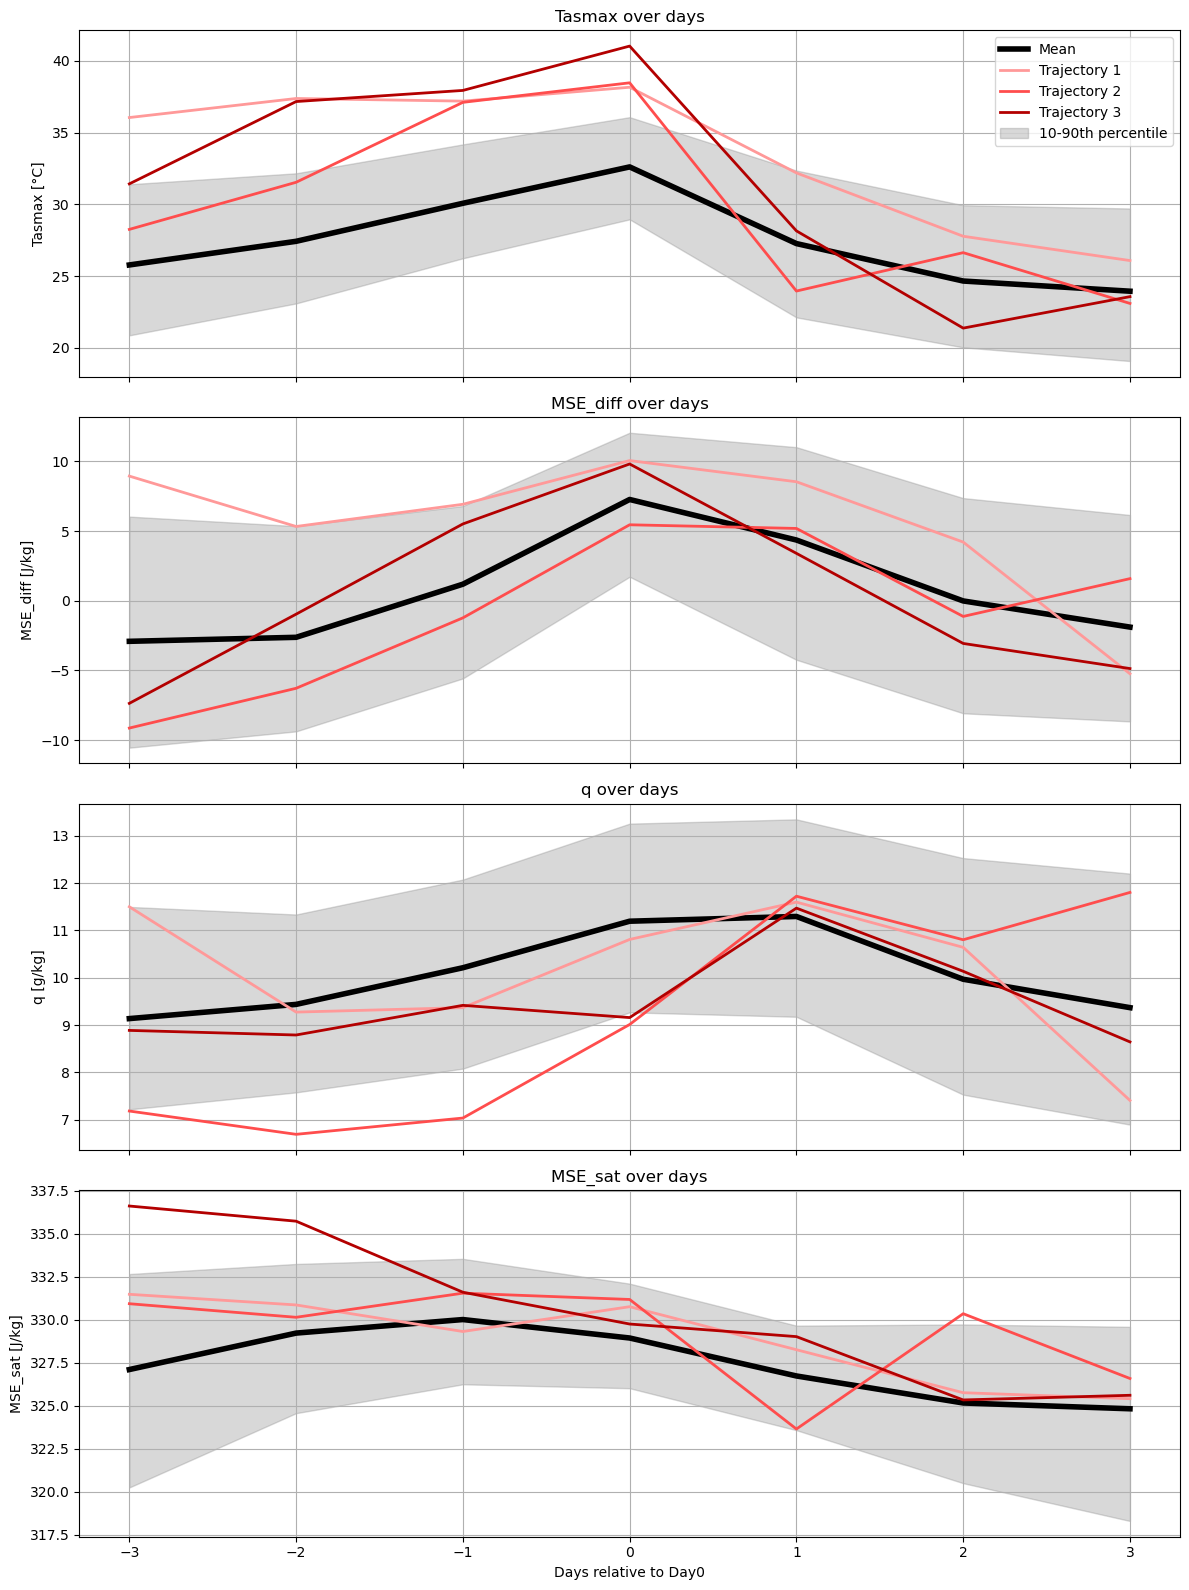

In [69]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15   # dims: composite_year, time, lat, lon
mse = ds["mse"]                  # dims: composite_year, time, lat, lon
mse_sat = ds["mse_sat"]          # dims: composite_year, time, lat, lon
q = ds["q"] * 1e3                # g/kg

# Flatten all spatial dims
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))  # composite_year, time, space

tas_flat = flatten(tasmax)
mse_diff_flat = flatten(mse - mse_sat)
q_flat = flatten(q)
mse_sat_flat = flatten(mse_sat)

# Select 3 hottest Day0 trajectories
day0 = 3
tas_day0 = tas_flat[:, day0, :]
top3_idx = np.argsort(tas_day0.mean(axis=1))[-3:]  # top 3 hottest trajectories

# Compute percentiles and mean across composites & space
tas_p10_time = np.nanpercentile(tas_flat, 10, axis=(0,2))
tas_p90_time = np.nanpercentile(tas_flat, 90, axis=(0,2))
tas_mean_time = np.nanmean(tas_flat, axis=(0,2))

mse_diff_p10_time = np.nanpercentile(mse_diff_flat, 10, axis=(0,2))
mse_diff_p90_time = np.nanpercentile(mse_diff_flat, 90, axis=(0,2))
mse_diff_mean_time = np.nanmean(mse_diff_flat, axis=(0,2))

q_p10_time = np.nanpercentile(q_flat, 10, axis=(0,2))
q_p90_time = np.nanpercentile(q_flat, 90, axis=(0,2))
q_mean_time = np.nanmean(q_flat, axis=(0,2))

mse_sat_p10_time = np.nanpercentile(mse_sat_flat, 10, axis=(0,2))
mse_sat_p90_time = np.nanpercentile(mse_sat_flat, 90, axis=(0,2))
mse_sat_mean_time = np.nanmean(mse_sat_flat, axis=(0,2))

days = np.arange(tas_flat.shape[1]) - day0  # centered on Day0

# Shades of red for top 3 trajectories
colors_red = ["#ff9999", "#ff4d4d", "#b30000"]

# Create figure with 4 subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# ----------------------------
# Top panel: Tasmax
# ----------------------------
ax = axes[0]
ax.fill_between(days, tas_p10_time, tas_p90_time, color='grey', alpha=0.3, label='10-90th percentile')
ax.plot(days, tas_mean_time, color='black', lw=4, label='Mean')
for i, idx in enumerate(top3_idx):
    ax.plot(days, tas_flat[idx, :, :].mean(axis=1), lw=2, color=colors_red[i], label=f'Trajectory {i+1}')
ax.set_ylabel('Tasmax [°C]')
ax.set_title('Tasmax over days')
ax.grid()
ax.legend()

# ----------------------------
# Second panel: MSE_diff
# ----------------------------
ax = axes[1]
ax.fill_between(days, mse_diff_p10_time, mse_diff_p90_time, color='grey', alpha=0.3, label='10-90th percentile')
ax.plot(days, mse_diff_mean_time, color='black', lw=4, label='Mean')
for i, idx in enumerate(top3_idx):
    ax.plot(days, mse_diff_flat[idx, :, :].mean(axis=1), lw=2, color=colors_red[i], label=f'Trajectory {i+1}')
ax.set_ylabel('MSE_diff [J/kg]')
ax.set_title('MSE_diff over days')
ax.grid()

# ----------------------------
# Third panel: q
# ----------------------------
ax = axes[2]
ax.fill_between(days, q_p10_time, q_p90_time, color='grey', alpha=0.3, label='10-90th percentile')
ax.plot(days, q_mean_time, color='black', lw=4, label='Mean')
for i, idx in enumerate(top3_idx):
    ax.plot(days, q_flat[idx, :, :].mean(axis=1), lw=2, color=colors_red[i], label=f'Trajectory {i+1}')
ax.set_ylabel('q [g/kg]')
ax.set_title('q over days')
ax.grid()

# ----------------------------
# Fourth panel: MSE_sat
# ----------------------------
ax = axes[3]
ax.fill_between(days, mse_sat_p10_time, mse_sat_p90_time, color='grey', alpha=0.3, label='10-90th percentile')
ax.plot(days, mse_sat_mean_time, color='black', lw=4, label='Mean')
for i, idx in enumerate(top3_idx):
    ax.plot(days, mse_sat_flat[idx, :, :].mean(axis=1), lw=2, color=colors_red[i], label=f'Trajectory {i+1}')
ax.set_xlabel('Days relative to Day0')
ax.set_ylabel('MSE_sat [J/kg]')
ax.set_title('MSE_sat over days')
ax.grid()

plt.tight_layout()
plt.savefig('composite_top3_trajectories_with_q_mse_sat.pdf')
plt.show()


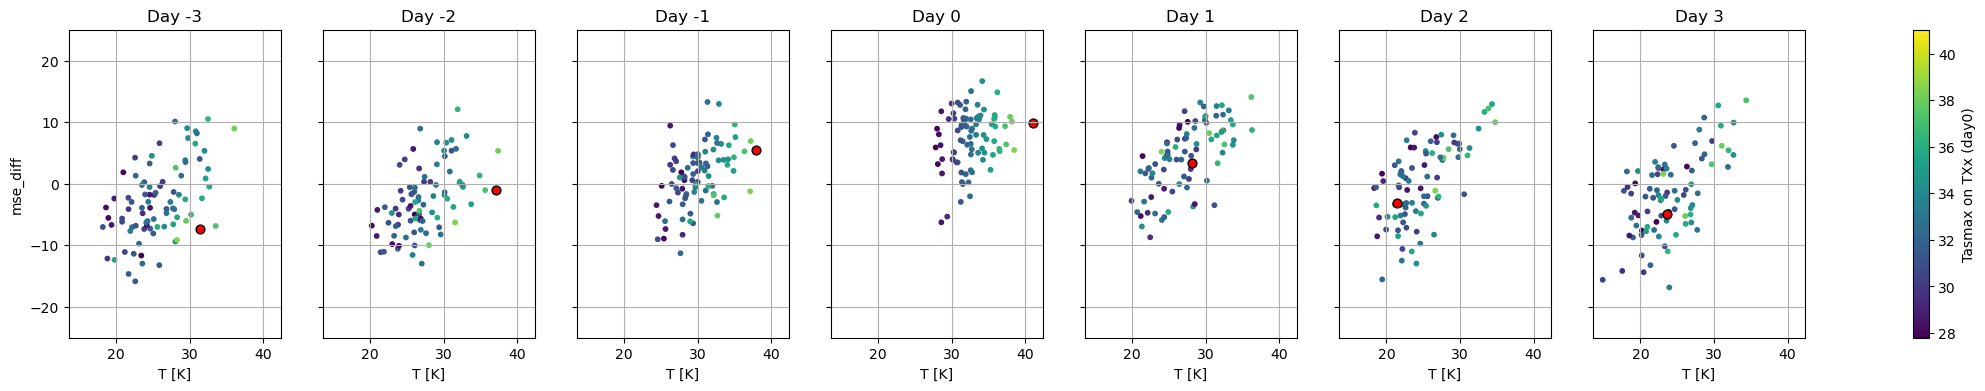

In [33]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned composite
ds = composite_ds

# Variables
tasmax = ds["tasmax"] - 273.15      # dims: composite_year, time, lat, lon
q = ds["tasmax"]   - 273.15                       # dims: composite_year, lev, lat, lon
mse = ds["mse"]                      # dims: composite_year, time, lat, lon, lev
mse_sat = ds["mse_sat"]              # dims: composite_year, time, lat, lon

# Select single level for q if multiple levs exist
# e.g., lowest level
if 'lev' in q.dims:
    q = q.isel(lev=0)

# Flatten all spatial dims
def flatten(da):
    return da.values.reshape((da.shape[0], da.shape[1], -1))  # composite_year, time, space

tas_flat = flatten(tasmax)
q_flat = flatten(q)
mse_diff_flat = flatten(mse - mse_sat)

# Color based on day0 Tasmax
c = tas_flat[:, 3, :].ravel()  # day0 = index 3
c_min, c_max = c.min(), c.max()

# Identify the 5 hottest day0 points
top5_idx = np.argsort(c)[-1:]

# Create figure with 7 subplots
fig, axes = plt.subplots(1, 7, figsize=(28, 4), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    y = mse_diff_flat[:, i, :].ravel()        # Tasmax at current day
    x = q_flat[:, i, :].ravel()          # q at current day

    # Scatter for all points
    sc = ax.scatter(
        x, y,
        c=c,           # color = TXx day Tasmax
        vmin=c_min,
        vmax=c_max,
        s=10,
        alpha=1.0
    )

    # Highlight top5 hottest day0 points in red
    ax.scatter(
        x[top5_idx],
        y[top5_idx],
        color='red',
        edgecolor='black',
        s=40,
        label='Top 5 hottest day0'
    )

    ax.set_title(f"Day {i-3}")
    ax.set_xlabel("T [K]")
    #ax.set_xlim(0.003, 0.018)
    ax.set_ylim(-25, 25)
    ax.grid()
    if i == 0:
        ax.set_ylabel("mse_diff")

# Shared colorbar
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical')
cbar.set_label("Tasmax on TXx (day0)")

#plt.tight_layout()
plt.savefig('composite_q_mse_era5.pdf')
plt.show()


In [40]:
import numpy as np

# Given values
T_C = 40.0                   # temperature in °C
T_K = T_C + 273.15
q = 0.015                      # specific humidity [kg/kg]
p = 1013.25e2                 # surface pressure in Pa (1013.25 hPa)

# Saturation vapor pressure (hPa) using Tetens formula
e_s_hPa = 6.112 * np.exp(17.67 * T_C / (T_C + 243.5))

# Actual vapor pressure (Pa → hPa)
e = q * p / (0.622 + q) / 100  # convert Pa → hPa

# Relative humidity %
RH = (e / e_s_hPa) * 100

print(f"Relative Humidity at {T_C}°C and q={q} kg/kg: {RH:.2f} %")


Relative Humidity at 40.0°C and q=0.015 kg/kg: 32.27 %


In [46]:
# For single grid point (lat=0, lon=0)
day0_tasmax_point = composite_ds["tasmax"].isel(time=3)
hottest_year_idx = day0_tasmax_point.argmax().item()
hottest_year = composite_ds["composite_year"].values[hottest_year_idx]

print("Hottest year at this location:", hottest_year)


Hottest year at this location: 2019


In [48]:
day0_tasmax_point-273.15

<xarray.DataArray 'tasmax' (composite_year: 85)>
array([30.235016, 31.935333, 31.212738, 34.221222, 31.368927, 33.56717 ,
       32.746246, 36.50168 , 31.850372, 32.70816 , 30.62497 , 27.795807,
       35.585663, 31.488312, 31.186737, 30.303986, 28.462433, 34.124725,
       27.985748, 32.552826, 28.665192, 32.463623, 30.790344, 30.202545,
       33.62018 , 28.681915, 29.562378, 31.345001, 32.00821 , 30.781769,
       29.960297, 30.103302, 28.56015 , 31.598969, 31.889313, 34.31259 ,
       34.111847, 28.090698, 28.22757 , 30.10022 , 30.795319, 30.347595,
       31.306427, 31.954376, 33.287384, 31.552032, 32.74948 , 31.299347,
       29.36618 , 32.43982 , 35.253815, 31.709473, 33.710724, 28.565704,
       33.364838, 34.361053, 32.08548 , 32.56778 , 36.438263, 31.116577,
       31.288025, 33.29306 , 32.629364, 38.162018, 32.58908 , 32.610992,
       35.90915 , 32.262695, 32.555847, 35.747833, 33.896057, 35.7464  ,
       37.373566, 34.694946, 33.49359 , 37.908722, 35.43402 , 35.82025 ,
       35.83963 , 41.030212, 37.229523, 31.469727, 38.470367, 34.4281  ,
       36.186676], dtype=float32)
Coordinates:
  * composite_year  (composite_year) int64 1940 1941 1942 ... 2022 2023 2024
    time            int64 0
    plev            float64 5e+04